# Canonical Cortical Column Dynamics

**SC-NeuroCore** — the Potjans & Diesmann (2014) eight-population laminar microcircuit.

`CorticalColumn` implements the canonical cortical microcircuit of
Potjans & Diesmann (2014): eight populations (an excitatory and an
inhibitory group in each of layers 2/3, 4, 5 and 6), wired with the
published layer-resolved connectivity and driven **only** by a
layer-specific background Poisson input. No external stimulus is
injected — the network *self-generates* the experimentally observed
**asynchronous-irregular** state, in which every population settles to
its own characteristic low firing rate.

This notebook demonstrates:
1. **Self-generated activity** — the circuit reaches a stable AI state from background drive alone
2. **Layer-resolved spike rasters** — per-population activity
3. **Population firing rates over time** — the approach to steady state
4. **Published fidelity** — steady-state rates against Potjans & Diesmann (2014) Table 4

> **Runtime note:** the simulation below integrates ~7,700 neurons for
> 600 ms (6,000 timesteps in pure Python), so it takes a couple of
> minutes. Rendered outputs are included so the results can be read
> without re-running.

> © 1998–2026 Miroslav Šotek. All rights reserved.  
> License: GNU AFFERO GENERAL PUBLIC LICENSE v3 | Commercial Licensing Available  
> Contact: www.anulum.li | protoscience@anulum.li

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sc_neurocore.network.cortical_column import CorticalColumn, POPULATIONS

print("SC-NeuroCore cortical column demo")
print("Populations:", ", ".join(POPULATIONS))

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


SC-NeuroCore cortical column demo
Populations: L23e, L23i, L4e, L4i, L5e, L5i, L6e, L6i


## 1. Build and simulate the column

In [2]:
# Published lower-bound scale: 0.1 -> ~7,700 neurons, the smallest
# size that reproduces the Potjans Table 4 asynchronous-irregular
# rates within tolerance. scale_correction=True preserves the
# full-scale synaptic in-degree (van Albada et al. 2015).
col = CorticalColumn(scale=0.1, scale_correction=True, seed=42)

print(f"Total neurons: {col.n_total}")
for p in POPULATIONS:
    print(f"  {p:5s}: {col.sizes[p]:5d} cells")

# Integrate for 600 ms at 0.1 ms resolution (6,000 steps).
rasters = col.simulate(duration_ms=600.0, dt=0.1)

# Mean firing rate per population, discarding the 200 ms
# construction transient.
rates = col.population_rates(rasters, dt=0.1, burn_in_ms=200.0)
print("\nSteady-state rates (200-600 ms):")
for p in POPULATIONS:
    print(f"  {p:5s}: {rates[p]:6.2f} Hz")

Total neurons: 7717
  L23e :  2068 cells
  L23i :   583 cells
  L4e  :  2192 cells
  L4i  :   548 cells
  L5e  :   485 cells
  L5i  :   106 cells
  L6e  :  1440 cells
  L6i  :   295 cells



Steady-state rates (200-600 ms):
  L23e :   0.60 Hz
  L23i :   3.36 Hz
  L4e  :   2.95 Hz
  L4i  :   6.82 Hz
  L5e  :  14.04 Hz
  L5i  :  11.98 Hz
  L6e  :   2.88 Hz
  L6i  :   9.81 Hz


## 2. Layer-Resolved Spike Rasters

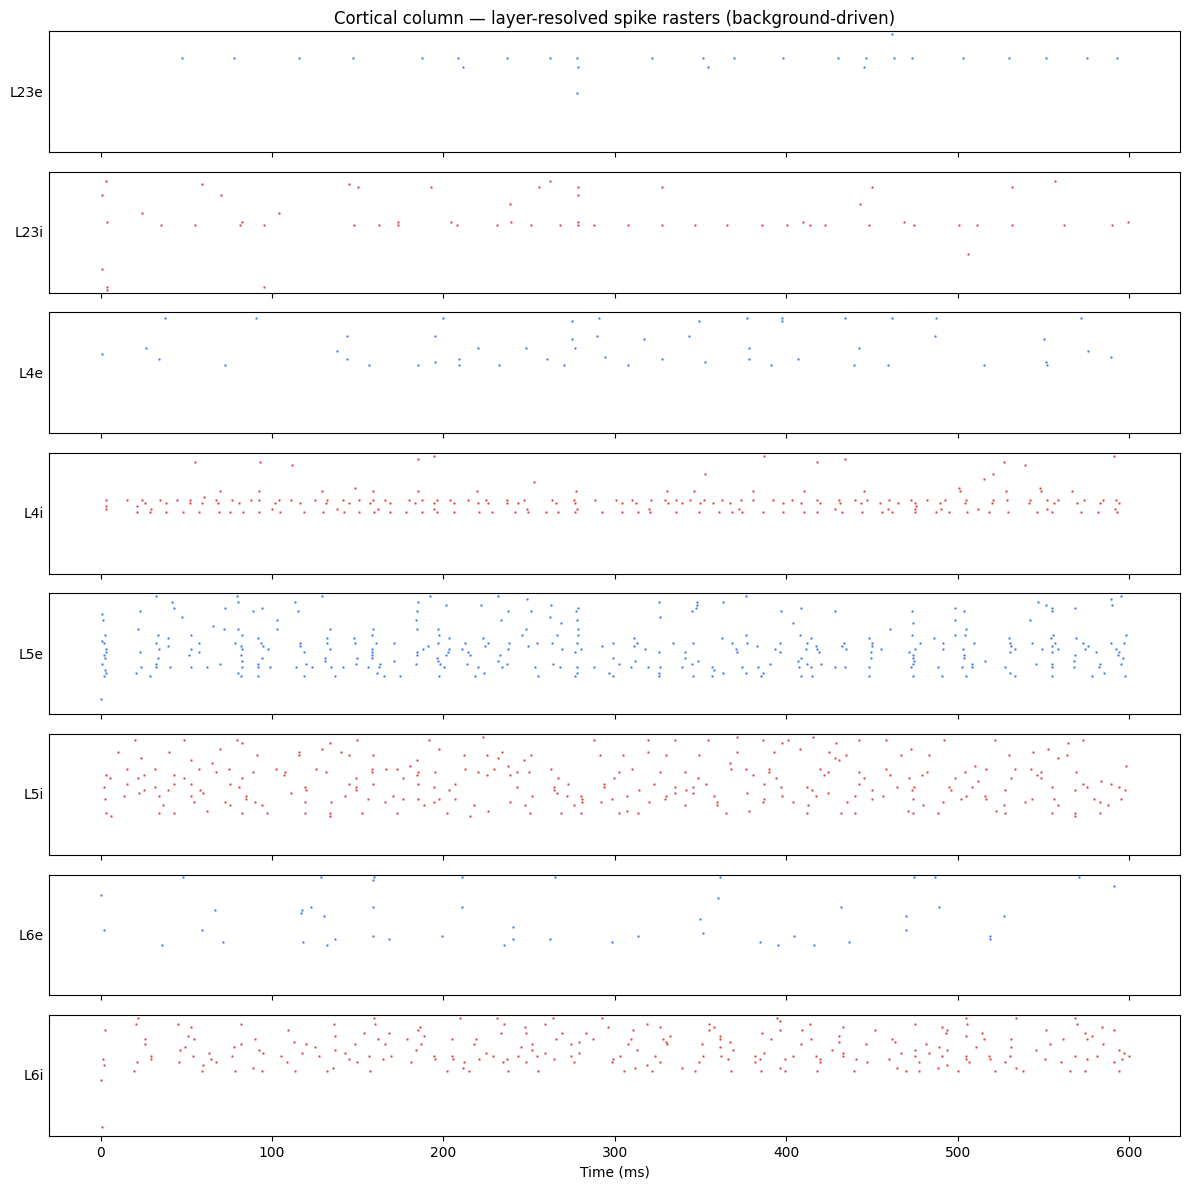

In [3]:
dt = 0.1
n_show = 40  # neurons per population to display

fig, axes = plt.subplots(len(POPULATIONS), 1, figsize=(12, 12), sharex=True)
colours = {"e": "#2563EB", "i": "#DC2626"}

for ax, p in zip(axes, POPULATIONS):
    raster = rasters[p]                       # (n_steps, n_pop) bool
    n_pop = raster.shape[1]
    idx = np.unique(np.linspace(0, n_pop - 1, min(n_show, n_pop)).astype(int))
    colour = colours["i"] if p.endswith("i") else colours["e"]
    for row, n in enumerate(idx):
        t_ms = np.where(raster[:, n])[0] * dt
        ax.scatter(t_ms, np.full(t_ms.shape, row, dtype=float),
                   s=0.6, c=colour, alpha=0.7)
    ax.set_ylabel(p, rotation=0, ha="right", va="center")
    ax.set_ylim(-1, len(idx))
    ax.set_yticks([])

axes[0].set_title("Cortical column — layer-resolved spike rasters (background-driven)")
axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

## 3. Population Firing Rates Over Time

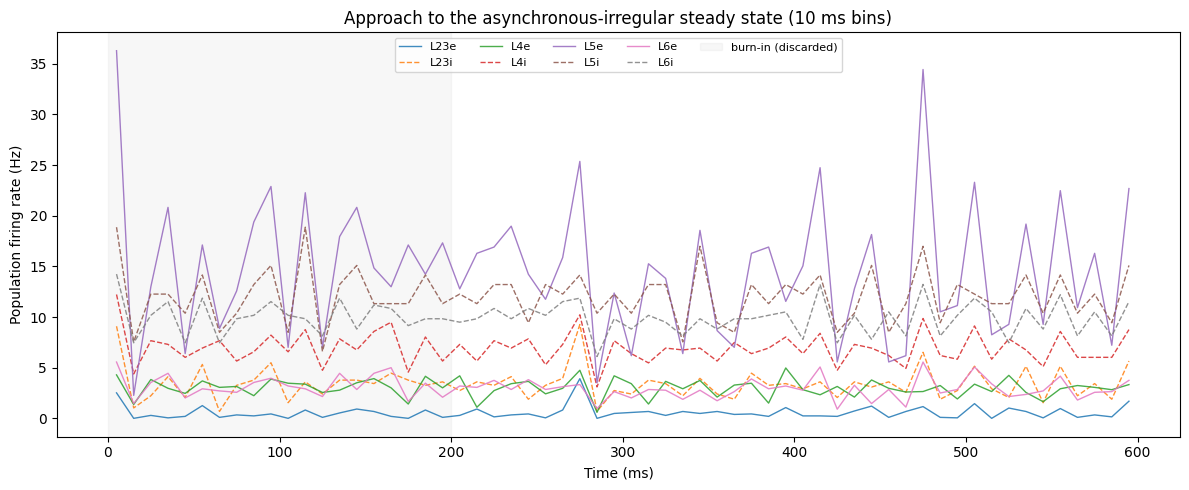

In [4]:
dt = 0.1
bin_ms = 10.0
bin_steps = int(bin_ms / dt)
n_steps = next(iter(rasters.values())).shape[0]
n_bins = n_steps // bin_steps

fig, ax = plt.subplots(figsize=(12, 5))
for p in POPULATIONS:
    raster = rasters[p]
    n_pop = raster.shape[1]
    r = np.zeros(n_bins)
    for b in range(n_bins):
        s0, s1 = b * bin_steps, (b + 1) * bin_steps
        r[b] = raster[s0:s1].sum() / (n_pop * bin_ms * 1e-3)
    t_bins = (np.arange(n_bins) + 0.5) * bin_ms
    style = "--" if p.endswith("i") else "-"
    ax.plot(t_bins, r, style, linewidth=1.0, label=p, alpha=0.85)

ax.axvspan(0, 200, alpha=0.06, color="gray", label="burn-in (discarded)")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Population firing rate (Hz)")
ax.set_title("Approach to the asynchronous-irregular steady state (10 ms bins)")
ax.legend(fontsize=8, ncol=5)
plt.tight_layout()
plt.show()

## 4. Published Fidelity — Potjans & Diesmann (2014) Table 4

The circuit is driven only by background noise, yet each population
settles to a distinct rate. Below we compare the measured
steady-state rates to the published Table 4 spontaneous rates.
Per-connection Gaussian synaptic delays (the default) break recurrent
synchrony and bring most populations within ~1.5× of the published
values; the deep excitatory layers (L5e, L6e) run somewhat hot at this
lower-bound scale and short integration. This mirrors SC-NeuroCore's
own fidelity test, which pins **at least 5 of 8 populations within
1.5×** of Table 4.

In [5]:
published = {  # Potjans & Diesmann (2014), Table 4 spontaneous rates (Hz)
    "L23e": 0.86, "L23i": 2.91,
    "L4e":  4.51, "L4i":  5.78,
    "L5e":  7.59, "L5i":  8.13,
    "L6e":  1.10, "L6i":  8.07,
}

print(f"{'Pop':<6s}{'Measured':>10s}{'Table 4':>10s}{'Ratio':>8s}   Band")
print("-" * 46)
within = 0
for p in POPULATIONS:
    ratio = rates[p] / published[p]
    in_band = 0.5 <= ratio <= 1.5
    within += int(in_band)
    flag = "within 1.5x" if in_band else "hot"
    print(f"{p:<6s}{rates[p]:10.2f}{published[p]:10.2f}{ratio:8.2f}   {flag}")
print("-" * 46)
print(f"{within}/8 populations within [0.5, 1.5]x of Potjans Table 4")

e_mean = np.mean([rates[p] for p in POPULATIONS if p.endswith("e")])
i_mean = np.mean([rates[p] for p in POPULATIONS if p.endswith("i")])
ok = "preserved" if i_mean > e_mean else "VIOLATED"
print(f"\nE/I asymmetry: mean excitatory {e_mean:.2f} Hz < mean inhibitory {i_mean:.2f} Hz ({ok})")

Pop     Measured   Table 4   Ratio   Band
----------------------------------------------
L23e        0.60      0.86    0.70   within 1.5x
L23i        3.36      2.91    1.16   within 1.5x
L4e         2.95      4.51    0.65   within 1.5x
L4i         6.82      5.78    1.18   within 1.5x
L5e        14.04      7.59    1.85   hot
L5i        11.98      8.13    1.47   within 1.5x
L6e         2.88      1.10    2.62   hot
L6i         9.81      8.07    1.22   within 1.5x
----------------------------------------------
6/8 populations within [0.5, 1.5]x of Potjans Table 4

E/I asymmetry: mean excitatory 5.12 Hz < mean inhibitory 7.99 Hz (preserved)


## Summary

| Layer | Excitatory | Inhibitory | Role |
|-------|-----------|-----------|------|
| L2/3 | L23e | L23i | Superficial recurrent processing, cortico-cortical output |
| L4 | L4e | L4i | Main thalamo-cortical input layer |
| L5 | L5e | L5i | Deep output to sub-cortical targets |
| L6 | L6e | L6i | Cortico-thalamic feedback |

The eight-population microcircuit self-generates the
asynchronous-irregular state observed in cortex — low, layer-specific
rates with inhibition faster than excitation — from background drive
alone, with no fitted external stimulus. It is the reference building
block for larger cortical models, and the same equations lower to
Verilog through SC-NeuroCore's equation-to-hardware pipeline.

**Reference:** Potjans, T. C. & Diesmann, M. (2014). *The cell-type
specific cortical microcircuit.* Cerebral Cortex 24(3): 785–806.